# PHQ-8 Depression Detection — HuBERT + MLP Regressor

**Architecture**: Frozen HuBERT (`facebook/hubert-base-ls960`) → mean-pooled 768-dim representation → `Linear(768, 256)` → `ReLU` → `Dropout` → `Linear(256, 1)`.

**Approach**: HuBERT weights are frozen throughout training. Features are extracted once and cached to disk. Training uses participant-level MSE — segment predictions are mean-pooled per participant before the loss is computed.

**Input**: Raw 16 kHz audio (`{id}_P.wav`) segmented into 8-second windows with 4-second (50%) overlap.

**Target**: PHQ-8 score (continuous, 0–24).

## 1. Install Dependencies

In [21]:
!pip install transformers librosa tqdm pandas numpy scipy --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [22]:
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import librosa
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from transformers import HubertModel, Wav2Vec2FeatureExtractor

print("Imports successful.")

Imports successful.


In [23]:
# --- Paths ---
BASE_DIR      = Path("..")
DATASET_DIR   = BASE_DIR / "dataset"
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV      = PROCESSED_DIR / "segment_metadata.csv"

FEATURE_CACHE = PROCESSED_DIR / "hubert_features.npz"   # saved/loaded here

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "hubert_linear"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Audio parameters (must match the preprocessing pipeline) ---
TARGET_SR  = 16_000
WINDOW_SEC = 8.0
HOP_SEC    = 4.0

# --- HuBERT ---
HUBERT_MODEL_NAME = "facebook/hubert-base-ls960"
HUBERT_DIM        = 768
FEAT_BATCH_SIZE   = 8       # segments per forward pass during extraction

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {DEVICE}")
if DEVICE.type == "cpu":
    print("  WARNING: No GPU detected — feature extraction will be slow.")
print(f"Feature cache  : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir : {SAVE_DIR.resolve()}")

Using device   : cuda
Feature cache  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\hubert_features.npz
Checkpoint dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\hubert_linear


## 3. Load Segment Metadata

Reuse the `segment_metadata.csv` produced by the audio preprocessing notebook.
It stores the train / dev / test split and PHQ-8 label for every segment.

In [24]:
meta = pd.read_csv(META_CSV)

# Participant-level summary (one row per participant)
participant_info = (
    meta.groupby("participant_id")
    .first()[["split", "phq_score"]]
    .reset_index()
)

print(f"Total segments   : {len(meta):,}")
print(f"Total participants: {len(participant_info)}")
print("\nSplit breakdown:")
for split, grp in participant_info.groupby("split"):
    display_name = "validation" if split == "dev" else split
    print(f"  {display_name:10s}: {len(grp):3d} participants")
print(f"\nPHQ-8 range: {meta['phq_score'].min():.0f} – {meta['phq_score'].max():.0f}")

Total segments   : 21,588
Total participants: 189

Split breakdown:
  validation:  35 participants
  test      :  47 participants
  train     : 107 participants

PHQ-8 range: 0 – 23


## 4. HuBERT Feature Extraction

Features are extracted once and cached to `processed/hubert_features.npz`.
On subsequent runs the cache is loaded directly — no GPU needed.

In [25]:
if FEATURE_CACHE.exists():
    # ── Load from cache ──────────────────────────────────────────────────────
    print(f"Cache found — loading features from {FEATURE_CACHE.name} …")
    cache = np.load(FEATURE_CACHE, allow_pickle=False)
    all_feats_np  = cache["feats"]      # (N, 768)
    all_scores_np = cache["phq_scores"] # (N,)
    all_pids_np   = cache["pids"]       # (N,)
    all_splits_np = cache["splits"]     # (N,)  dtype=bytes, decode below

    in_memory = {"train": [], "dev": [], "test": []}
    for feat, score, pid, split in zip(all_feats_np,
                                       all_scores_np,
                                       all_pids_np,
                                       all_splits_np):
        in_memory[split.decode()].append((feat, float(score), int(pid)))

    rows = [{"participant_id": int(pid),
             "phq_score":      float(score),
             "split":          split.decode()}
            for pid, score, split in zip(all_pids_np,
                                         all_scores_np,
                                         all_splits_np)]
    feature_meta = pd.DataFrame(rows)
    print(f"Loaded {len(feature_meta):,} segments.")

else:
    # ── Extract and save ─────────────────────────────────────────────────────
    print(f"No cache found — extracting HuBERT features using '{HUBERT_MODEL_NAME}' …")

    wav2vec_fe = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL_NAME)
    hubert     = HubertModel.from_pretrained(HUBERT_MODEL_NAME).to(DEVICE)
    hubert.eval()
    for param in hubert.parameters():
        param.requires_grad_(False)

    window_samples = int(WINDOW_SEC * TARGET_SR)
    hop_samples    = int(HOP_SEC    * TARGET_SR)

    in_memory = {"train": [], "dev": [], "test": []}
    rows = []

    # accumulators for saving
    save_feats, save_scores, save_pids, save_splits = [], [], [], []

    for _, p_row in tqdm(participant_info.iterrows(),
                         total=len(participant_info),
                         desc="Participants"):

        pid       = int(p_row["participant_id"])
        split     = p_row["split"]
        phq_score = p_row["phq_score"]

        wav_path = DATASET_DIR / f"{pid}_P.wav"
        if not wav_path.exists():
            print(f"  [SKIP] {wav_path.name} not found")
            continue

        waveform, _ = librosa.load(wav_path, sr=TARGET_SR, mono=True)

        segments, start = [], 0
        while start + window_samples <= len(waveform):
            segments.append(waveform[start : start + window_samples])
            start += hop_samples

        if not segments:
            continue

        all_feats = []
        for i in range(0, len(segments), FEAT_BATCH_SIZE):
            batch  = segments[i : i + FEAT_BATCH_SIZE]
            inputs = wav2vec_fe(
                batch,
                sampling_rate=TARGET_SR,
                return_tensors="pt",
                padding=True,
            )
            input_values = inputs.input_values.to(DEVICE)
            with torch.no_grad():
                hidden = hubert(input_values).last_hidden_state  # (B, T, 768)
                feats  = hidden.mean(dim=1)                       # (B, 768)
            all_feats.append(feats.cpu().numpy())

        all_feats = np.concatenate(all_feats, axis=0)  # (n_segs, 768)

        for seg_idx, feat in enumerate(all_feats):
            in_memory[split].append((feat, phq_score, pid))
            rows.append({"participant_id": pid,
                         "phq_score": phq_score,
                         "split": split})
            save_feats.append(feat)
            save_scores.append(phq_score)
            save_pids.append(pid)
            save_splits.append(split.encode())   # bytes for npz

    feature_meta = pd.DataFrame(rows)

    # Save cache
    np.savez(
        FEATURE_CACHE,
        feats      = np.array(save_feats,  dtype=np.float32),
        phq_scores = np.array(save_scores, dtype=np.float32),
        pids       = np.array(save_pids,   dtype=np.int32),
        splits     = np.array(save_splits),
    )
    print(f"\nDone. {len(feature_meta):,} feature vectors extracted and cached to "
          f"{FEATURE_CACHE.name}.")

    del hubert, wav2vec_fe
    torch.cuda.empty_cache()

print(feature_meta["split"].value_counts().rename(index={"dev": "validation"}).to_string())

Cache found — loading features from hubert_features.npz …
Loaded 21,588 segments.
split
train         11362
test           5904
validation     4322


## 5. Training Configuration

Adjust hyperparameters here without re-running feature extraction.

In [33]:
# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE   = 8    # participants per gradient update
NUM_EPOCHS               = 500
LEARNING_RATE            = 1e-4
WEIGHT_DECAY             = 1e-3
DROPOUT                  = 0.2
EARLY_STOPPING_PATIENCE  = 50
CHECKPOINT_FREQ          = 10
NUM_WORKERS              = 0

# BATCH_SIZE is still used by the DataLoaders for validation/test evaluation
BATCH_SIZE = 64

print("Training configuration set.")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs")

Training configuration set.
  Participant batch size : 8
  Epochs                 : 500
  Learning rate          : 0.0001
  Weight decay           : 0.001
  Dropout                : 0.2
  Early stopping         : 50 epochs


## 6. Dataset & DataLoaders

In [34]:
class HuBERTFeatureDataset(Dataset):
    """
    Wraps in-memory HuBERT features (768-dim numpy arrays).

    Returns
    -------
    feat  : torch.FloatTensor  (768,)
    label : torch.FloatTensor  scalar — PHQ-8 score
    pid   : torch.LongTensor   scalar — participant ID (for aggregation)
    """
    def __init__(self, records):
        # records: list of (feat_array, phq_score, participant_id)
        self.records = records

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        feat_arr, phq_score, pid = self.records[idx]
        feat  = torch.from_numpy(feat_arr.astype(np.float32))    # (768,)
        label = torch.tensor(float(phq_score), dtype=torch.float32)
        pid   = torch.tensor(int(pid), dtype=torch.long)
        return feat, label, pid


def build_loaders(in_memory: dict, batch_size: int, num_workers: int):
    # Note: training is done participant-level (see train_epoch),
    # so these loaders are used for validation/test evaluation only.
    loaders = {}
    for split in ("dev", "test"):
        ds = HuBERTFeatureDataset(in_memory[split])
        loaders[split] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True,
        )
        display_name = "validation" if split == "dev" else split
        print(f"  {display_name:10s}: {len(ds):6,} segments")
    return loaders


print("Building data loaders…")
loaders     = build_loaders(in_memory, BATCH_SIZE, NUM_WORKERS)
val_loader  = loaders["dev"]
test_loader = loaders["test"]

Building data loaders…
  validation:  4,322 segments
  test      :  5,904 segments


## 7. Model — HuBERT Regressor

In [35]:
class HuBERTRegressor(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=64, dropout=0.5):
        super(HuBERTRegressor, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(x).squeeze(1)   # (B,)


model = HuBERTRegressor(dropout=DROPOUT).to(DEVICE)   # use config DROPOUT

with torch.no_grad():
    dummy = torch.zeros(4, HUBERT_DIM, device=DEVICE)
    print(f"Output shape: {model(dummy).shape}  (expected: torch.Size([4]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(f"Dropout: {DROPOUT}")

Output shape: torch.Size([4])  (expected: torch.Size([4]))
Trainable parameters: 49,281
Dropout: 0.2


## 8. Training Loop

In [36]:
from collections import defaultdict

criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_val_loss     = float("inf")
epochs_no_improve = 0

# Pre-group train segments by participant (done once, reused every epoch)
train_by_pid = defaultdict(lambda: {"feats": [], "label": None})
for feat, score, pid in in_memory["train"]:
    train_by_pid[pid]["feats"].append(feat)
    train_by_pid[pid]["label"] = score
train_participants = list(train_by_pid.values())
print(f"Training on {len(train_participants)} participants.")


def train_epoch():
    """
    Participant-level training pass.
    For each participant: forward all segments → mean-pool predictions →
    compute MSE against participant label → backprop.
    Gradients are accumulated over PARTICIPANT_BATCH_SIZE participants
    before each optimizer step.
    """
    model.train()
    # shuffle participant order each epoch
    idx = torch.randperm(len(train_participants)).tolist()

    # split into batches upfront so each batch knows its own size
    batches = [idx[i : i + PARTICIPANT_BATCH_SIZE]
               for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)]

    total_loss, n = 0.0, 0

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            p = train_participants[i]
            feats = torch.tensor(
                np.array(p["feats"]), dtype=torch.float32, device=DEVICE
            )                                               # (n_segs, 768)
            label = torch.tensor(
                [p["label"]], dtype=torch.float32, device=DEVICE
            )                                               # (1,)

            pred_mean = model(feats).mean(dim=0, keepdim=True)  # (1,)
            loss = criterion(pred_mean, label) / batch_size     # normalize by actual batch size
            loss.backward()

            total_loss += loss.item() * batch_size
            n          += 1

        optimizer.step()

    return total_loss / n


def evaluate_participant(loader):
    """Participant-level evaluation via the DataLoader."""
    model.eval()
    records = []
    with torch.no_grad():
        for feats, labels, pids in loader:
            feats = feats.to(DEVICE, non_blocking=True)
            preds = model(feats).cpu().numpy()
            for pid, pred, label in zip(pids.numpy(), preds, labels.numpy()):
                records.append((int(pid), float(pred), float(label)))

    df  = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    agg = df.groupby("participant_id").agg(
        pred  =("pred",  "mean"),
        label =("label", "first"),
    ).reset_index()

    mse  = float(np.mean((agg["pred"].values - agg["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, agg


for epoch in range(1, NUM_EPOCHS + 1):

    train_mse            = train_epoch()
    val_mse, val_rmse, _ = evaluate_participant(val_loader)

    history["train_loss"].append(train_mse)
    history["val_loss"].append(val_mse)
    history["val_rmse"].append(val_rmse)

    print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}]  "
          f"Train MSE: {train_mse:.4f}  "
          f"Val MSE: {val_mse:.4f}  "
          f"Val RMSE: {val_rmse:.4f}")

    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_HuBERT_linear.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "val_mse":              val_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved → {ckpt_path.name}")

    if val_mse < best_val_loss:
        best_val_loss     = val_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "HuBERT_linear_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_mse":              val_mse,
            "val_rmse":             val_rmse,
        }, best_path)
        print(f"  Best model saved → {best_path.name}  (val MSE {val_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for "
                  f"{EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best validation MSE  : {best_val_loss:.4f}")
print(f"Best validation RMSE : {best_val_loss ** 0.5:.4f}  PHQ-8 points")

Training on 107 participants.
Epoch [  1/500]  Train MSE: 67.7464  Val MSE: 92.6945  Val RMSE: 9.6278
  Best model saved → HuBERT_linear_best.pth  (val MSE 92.6945)
Epoch [  2/500]  Train MSE: 65.8737  Val MSE: 90.3694  Val RMSE: 9.5063
  Best model saved → HuBERT_linear_best.pth  (val MSE 90.3694)
Epoch [  3/500]  Train MSE: 63.8807  Val MSE: 87.7545  Val RMSE: 9.3677
  Best model saved → HuBERT_linear_best.pth  (val MSE 87.7545)
Epoch [  4/500]  Train MSE: 61.6582  Val MSE: 85.2808  Val RMSE: 9.2348
  Best model saved → HuBERT_linear_best.pth  (val MSE 85.2808)
Epoch [  5/500]  Train MSE: 59.6031  Val MSE: 82.6039  Val RMSE: 9.0887
  Best model saved → HuBERT_linear_best.pth  (val MSE 82.6039)
Epoch [  6/500]  Train MSE: 57.3669  Val MSE: 79.9351  Val RMSE: 8.9406
  Best model saved → HuBERT_linear_best.pth  (val MSE 79.9351)
Epoch [  7/500]  Train MSE: 55.1237  Val MSE: 77.3439  Val RMSE: 8.7945
  Best model saved → HuBERT_linear_best.pth  (val MSE 77.3439)
Epoch [  8/500]  Train MS

## 9. Training Curves

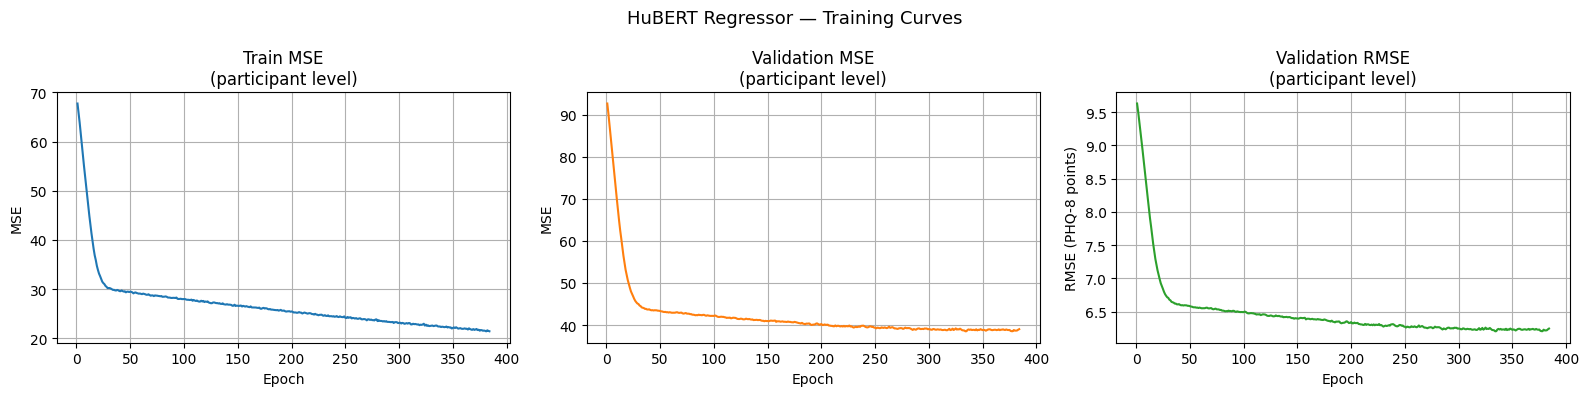

In [37]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Train MSE\n(participant level)")
axes[0].grid(True)

axes[1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Validation MSE\n(participant level)")
axes[1].grid(True)

axes[2].plot(epochs_ran, history["val_rmse"], color="tab:green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE (PHQ-8 points)")
axes[2].set_title("Validation RMSE\n(participant level)")
axes[2].grid(True)

plt.suptitle("HuBERT Regressor — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Evaluation on Test Set

Loads the best checkpoint and reports participant-level metrics.
Each participant's segment predictions are averaged into a single score before computing metrics.

In [38]:
# Load best weights
best_ckpt = torch.load(
    SAVE_DIR / "HuBERT_linear_best.pth",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(val MSE {best_ckpt['val_mse']:.4f})")

# Participant-level predictions on the test set
_, _, test_agg = evaluate_participant(test_loader)

all_preds  = test_agg["pred"].values
all_labels = test_agg["label"].values

print(f"  Participants evaluated: {len(test_agg)}")

test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print("\n── Test-set results (participant level) ───────────")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 334  (val MSE 38.4935)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 41.2218
  RMSE      : 6.4204  PHQ-8 points
  MAE       : 5.3799  PHQ-8 points
  Pearson r : 0.0905


## 11. Prediction Distribution

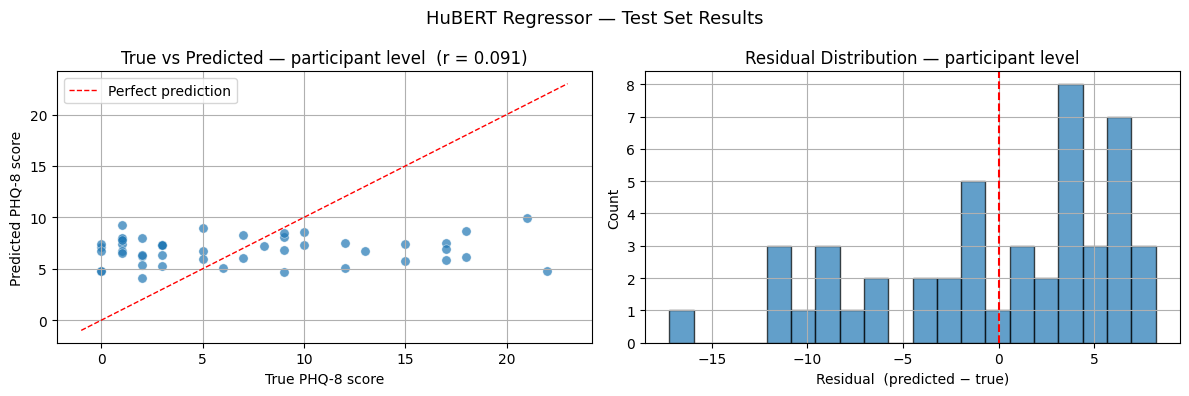

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: true vs predicted (one dot per participant)
axes[0].scatter(all_labels, all_preds, alpha=0.7, s=45, edgecolors="white", linewidths=0.4)
lo = min(all_labels.min(), all_preds.min()) - 1
hi = max(all_labels.max(), all_preds.max()) + 1
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted — participant level  (r = {test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

# Residuals histogram
residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual  (predicted − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — participant level")
axes[1].grid(True)

plt.suptitle("HuBERT Regressor — Test Set Results", fontsize=13)
plt.tight_layout()
plt.show()